In [5]:
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, AIMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv

In [6]:
load_dotenv()

True

In [7]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [9]:
def chat_node(state: ChatState):
    decision =   interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "intruction": "Approve this question? yesy/no"
    })
    if decision["approved"]=="no":
        return {"messages": [AIMessage(content="Not Approved.")]}
    else:
        response= llm.invoke(state["messages"])
        return {"messages":[response]}

In [10]:
## Build the graph : START -> chat -> END
builder= StateGraph(ChatState)
builder.add_node("chat",chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat",END)

## Checkpointer is required for interrupt
checkpointer= MemorySaver()

## Compile the app
app=builder.compile(checkpointer=checkpointer)

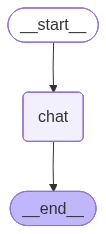

In [11]:
app

In [27]:
## create a new thread id for this conversation
config= {"configurable":{"thread_id":'1234'}}

##----STEP 1: User asks a question----
initial_output= {
    "messages":[
        ("user","Explain gradient descent in very simple terms.")
    ]
}

## Invoke the graph for the first time
result=app.invoke(initial_output, config=config)

In [28]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='39a3ee11-a378-4d86-a087-aa2dd331d366'),
  AIMessage(content='Imagine you\'re standing on a hill, and you want to get to the bottom. But it\'s foggy, so you can\'t see the whole hill. Here\'s how you can use "gradient descent" to get down:\n\n1. **Take a small step**: Move your feet a little bit in the direction that feels like it\'s downhill. You\'re not trying to jump all the way down, just take a tiny step.\n2. **Feel the ground**: Notice how steep the hill is where you just stepped. If it\'s still pretty steep, you know you\'re going in the right direction (downhill).\n3. **Take another step**: Move your feet again, a little bit more, in the same direction. You\'re still trying to go downhill.\n4. **Repeat**: Keep taking small steps, feeling the ground, and adjusting your direction until you reach the bottom.\n\nIn machine learning, "gradient descent" 

In [29]:
message= result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'intruction': 'Approve this question? yesy/no'}

In [30]:
user_input= input(f'\n Backend message= {message} \n Approve this question? (y/n): ')

In [31]:
## Resume the graph with the approval decision
final_result= app.invoke(
    Command(resume={"approved":user_input}),
    config=config
)

In [32]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='39a3ee11-a378-4d86-a087-aa2dd331d366'), AIMessage(content='Imagine you\'re standing on a hill, and you want to get to the bottom. But it\'s foggy, so you can\'t see the whole hill. Here\'s how you can use "gradient descent" to get down:\n\n1. **Take a small step**: Move your feet a little bit in the direction that feels like it\'s downhill. You\'re not trying to jump all the way down, just take a tiny step.\n2. **Feel the ground**: Notice how steep the hill is where you just stepped. If it\'s still pretty steep, you know you\'re going in the right direction (downhill).\n3. **Take another step**: Move your feet again, a little bit more, in the same direction. You\'re still trying to go downhill.\n4. **Repeat**: Keep taking small steps, feeling the ground, and adjusting your direction until you reach the bottom.\n\nIn machine learning, "gradient descent" wo